In [69]:
import random
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import networkx as nx

In [ ]:
# DRAWING THE HYPERGRAPH

# Layout helper: compact "pile" positions with min distance
def generate_pile_positions(V, radius=1.0, min_dist=0.18, seed=4, max_tries=50_000):
    """
    Place nodes randomly in a disk of given radius, enforcing a minimum distance
    between any two nodes. Produces a compact 'pile' layout.

    Parameters
    ----------
    V : iterable
        Vertex labels.
    radius : float
        Maximum distance from the origin (compactness bound).
    min_dist : float
        Minimum allowed distance between any two vertices.
    seed : int
        RNG seed for reproducibility.
    max_tries : int
        Safety cap to avoid infinite loops if constraints are too strict.

    Returns
    -------
    pos : dict
        Mapping {v: (x,y)}.
    """
    random.seed(seed)
    pos = {}
    tries = 0

    for v in V:
        placed = False
        while not placed:
            tries += 1
            if tries > max_tries:
                raise RuntimeError(
                    "Could not place all vertices. Try decreasing min_dist or increasing radius."
                )

            # Sample uniformly in a disk
            r = radius * np.sqrt(random.random())
            theta = 2 * np.pi * random.random()
            x = r * np.cos(theta)
            y = r * np.sin(theta)

            # Enforce minimum distance to existing points
            if all(np.hypot(x - px, y - py) >= min_dist for px, py in pos.values()):
                pos[v] = (x, y)
                placed = True

    return pos


# Hypergraph drawing function (edges + hyperedges)
def draw_hypergraph_simplicial(
    n,
    edges=None,
    hyperedges=None,
    *,
    node_labels=False,
    radius=1.0,
    min_dist=0.18,
    layout_seed=4,
    node_size=30,
    node_color="#1f77b4",
    node_edgecolor="black",
    node_linewidth=0.6,
    edge_color="black",
    edge_width=1.0,
    face_color="#6baed6", 
    face_alpha=0.35,
    outline_color="#2171b5",
    outline_width=1.2,
    figsize=(6.5, 6.5),
    title=None,
    filename_base=None,
    dpi=400
):
    V = list(range(1, n + 1))
    edges = edges or []
    hyperedges = hyperedges or []

    # compact pile layout
    pos = generate_pile_positions(
        V,
        radius=radius,
        min_dist=min_dist,
        seed=layout_seed
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.axis("off")

    # Draw hyperedges (filled triangles with blue outline)
    for he in hyperedges:
        he = tuple(he)
        if len(he) < 3:
            continue

        pts = np.array([pos[v] for v in he])
        poly = Polygon(
            pts,
            closed=True,
            facecolor=face_color,
            edgecolor=outline_color,
            linewidth=outline_width,
            alpha=face_alpha,
            zorder=1
        )
        ax.add_patch(poly)

    # Draw 2-edges (black)
    for (u, v) in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2],
                color=edge_color,
                linewidth=edge_width,
                zorder=2)

    # Draw nodes
    xs = [pos[v][0] for v in V]
    ys = [pos[v][1] for v in V]
    ax.scatter(
        xs, ys,
        s=node_size,
        color=node_color,
        edgecolors=node_edgecolor,
        linewidths=node_linewidth,
        zorder=3
    )

    if node_labels:
        for v in V:
            x, y = pos[v]
            ax.text(x, y, str(v),
                    ha="center", va="center",
                    fontsize=8, color="white",
                    zorder=4)

    if title is not None:
        ax.set_title(title, fontsize=11)

    plt.tight_layout()

    if filename_base:
        plt.savefig(f"{filename_base}.png", dpi=dpi, bbox_inches="tight")
        plt.savefig(f"{filename_base}.pdf", bbox_inches="tight")

    plt.show()

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], [(1, 11), (1, 15), (2, 3), (2, 4), (2, 10), (2, 19), (4, 7), (5, 7), (5, 8), (6, 13), (7, 9), (8, 9), (9, 10), (9, 11), (10, 16), (11, 17), (11, 18), (13, 20), (15, 20), (16, 18)], [(2, 15, 20), (9, 15, 20)])


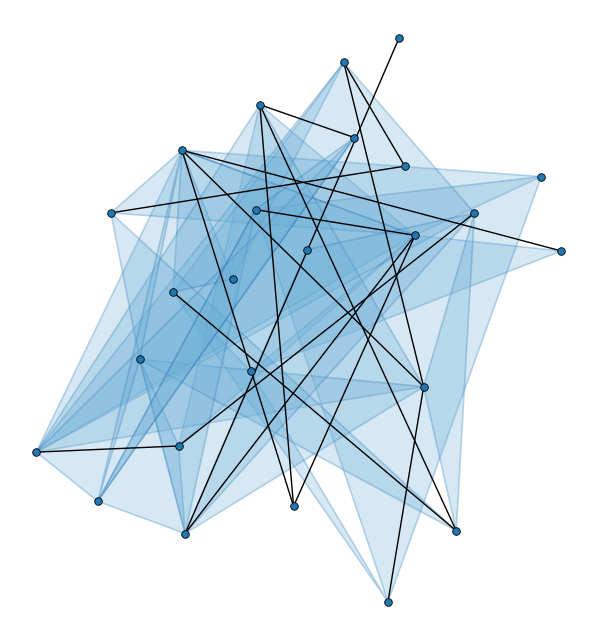

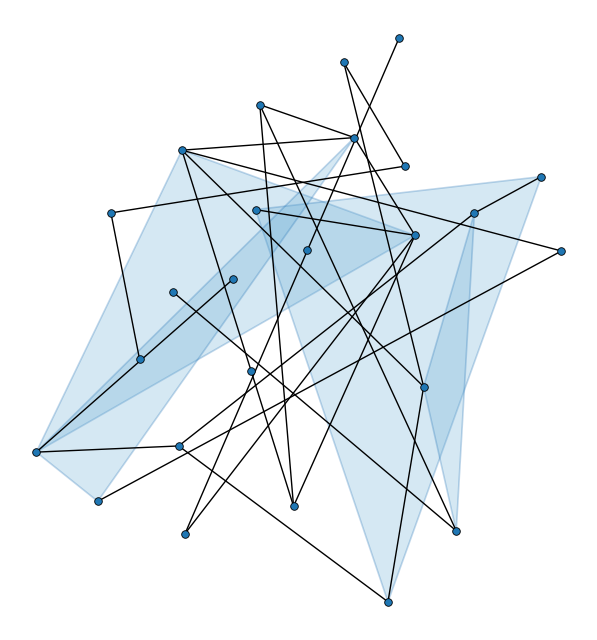

In [ ]:

# Generalized Erdős-Rényi

def er_2_3_hypergraph(n, p2, p3, seed=1):
    """
    Generate a generalized Erdős–Rényi hypergraph on vertices 1..n
    with:
        - 2-node edges generated with probability p2
        - 3-node hyperedges generated with probability p3

    Returns:
        V   : list of vertices
        E2  : list of 2-edges
        E3  : list of 3-hyperedges
    """
    random.seed(seed)

    V = list(range(1, n + 1))

    # Generate 2-edges
    E2 = [
        e for e in combinations(V, 2)
        if random.random() < p2
    ]

    # Generate 3-hyperedges
    E3 = [
        e for e in combinations(V, 3)
        if random.random() < p3
    ]

    return V, E2, E3

print(er_2_3_hypergraph(20, 0.06, 0.002))

n = 25

if __name__ == "__main__":
    V, E2, E3 = er_2_3_hypergraph(n=n, p2=0.03, p3=0.008, seed=1)

    draw_hypergraph_simplicial(
        n=n,
        edges=E2,              # these are the "true" 2-edges you generated
        hyperedges=E3,         # these are the 3-hyperedges you generated
        node_labels=False,
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="G25_first"
    )

if __name__ == "__main__":
    V, E2, E3 = er_2_3_hypergraph(n=n, p2=0.05, p3=0.002, seed=1)

    draw_hypergraph_simplicial(
        n=n,
        edges=E2,              # these are the "true" 2-edges you generated
        hyperedges=E3,         # these are the 3-hyperedges you generated
        node_labels=False,
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="G25_second"
    )

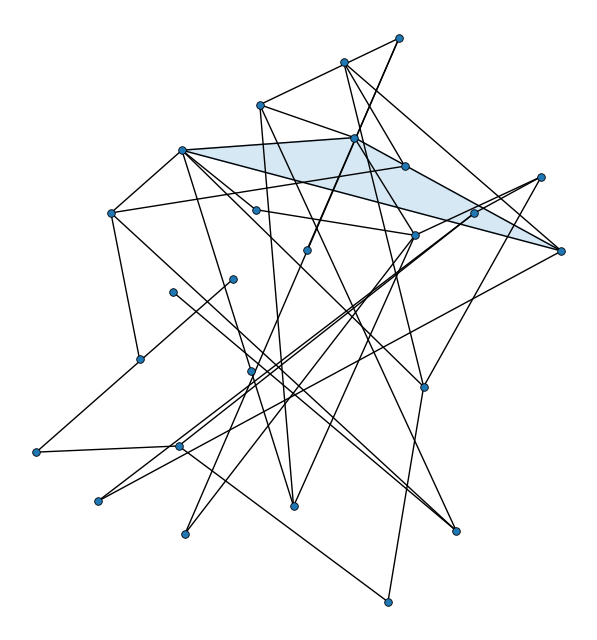

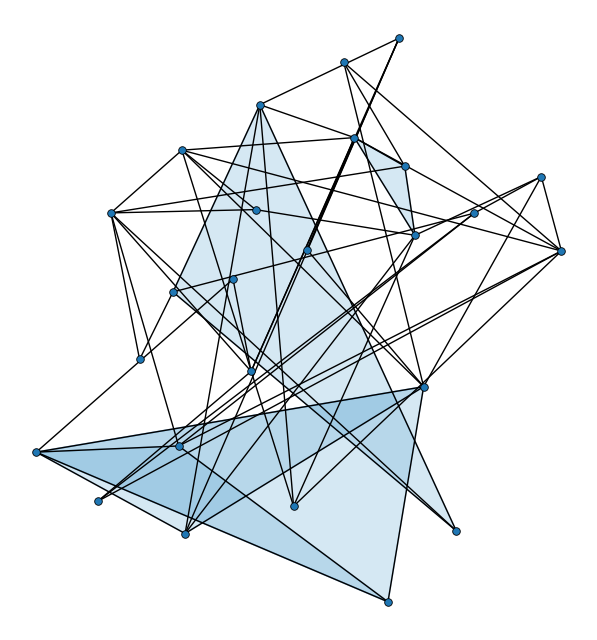

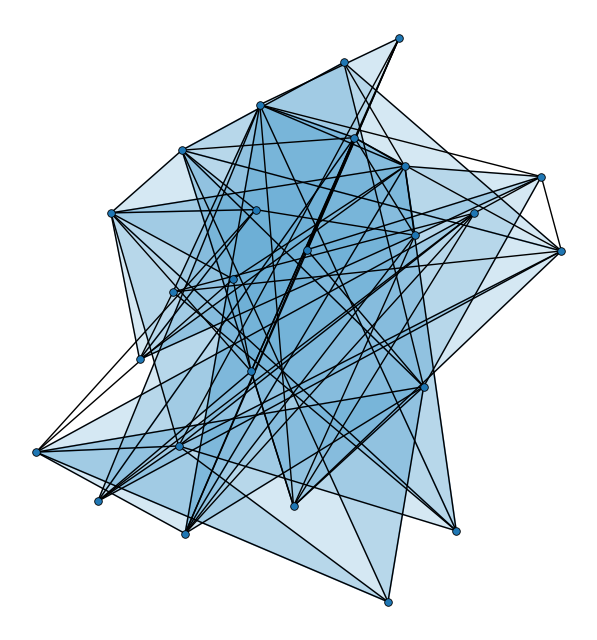

In [ ]:
# Recursive Erdős-Rényi hypergraph

def recursive_er_2_3_hypergraph(n, p1, p2, seed=1):
    """
    Recursive Erdős–Rényi hypergraph R(n,3,p1,p2).

    Layer 1 (r=2):
        Standard ER graph with probability p1.

    Layer 2 (r=3):
        A 3-edge {i,j,k} is included with probability p2
        ONLY IF all three pairs are present in the 2-layer.

    Returns
    -------
    V   : list of vertices
    E2  : list of 2-edges
    E3  : list of 3-hyperedges
    """
    random.seed(seed)

    V = list(range(1, n + 1))

    # Layer r = 2 (ER graph)
    E2 = [
        tuple(e)
        for e in combinations(V, 2)
        if random.random() < p1
    ]

    E2_set = set(E2)  # for fast lookup

    # Layer r = 3 (recursive condition)
    E3 = []

    for e in combinations(V, 3):

        # check recursive condition:
        # all 2-subsets must already exist
        pairs = list(combinations(e, 2))

        if all(tuple(pair) in E2_set for pair in pairs):

            # if eligible, include with probability p2
            if random.random() < p2:
                E3.append(tuple(e))

    return V, E2, E3

n = 25

if __name__ == "__main__":
    p1 = 0.1
    p2 = 0.5

    V, E2, E3 = recursive_er_2_3_hypergraph(
        n=n,
        p1=p1,
        p2=p2,
        seed=1
    )

    draw_hypergraph_simplicial(
        n=n,
        edges=E2,
        hyperedges=E3,
        node_labels=False,
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="R25_first"
    )

if __name__ == "__main__":
    p1 = 0.18
    p2 = 0.5

    V, E2, E3 = recursive_er_2_3_hypergraph(
        n=n,
        p1=p1,
        p2=p2,
        seed=1
    )

    draw_hypergraph_simplicial(
        n=n,
        edges=E2,
        hyperedges=E3,
        node_labels=False,
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="R25_second"
    )

if __name__ == "__main__":
    p1 = 0.25
    p2 = 0.7

    V, E2, E3 = recursive_er_2_3_hypergraph(
        n=n,
        p1=p1,
        p2=p2,
        seed=1
    )

    draw_hypergraph_simplicial(
        n=n,
        edges=E2,
        hyperedges=E3,
        node_labels=False,
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="R25_third"
    )


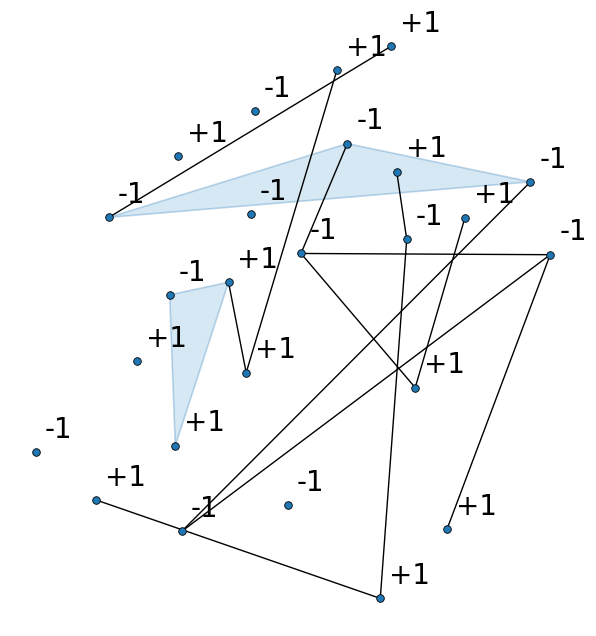

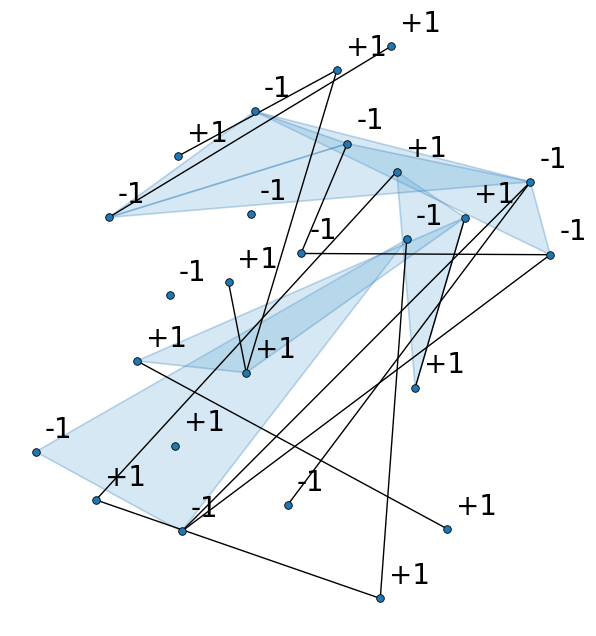

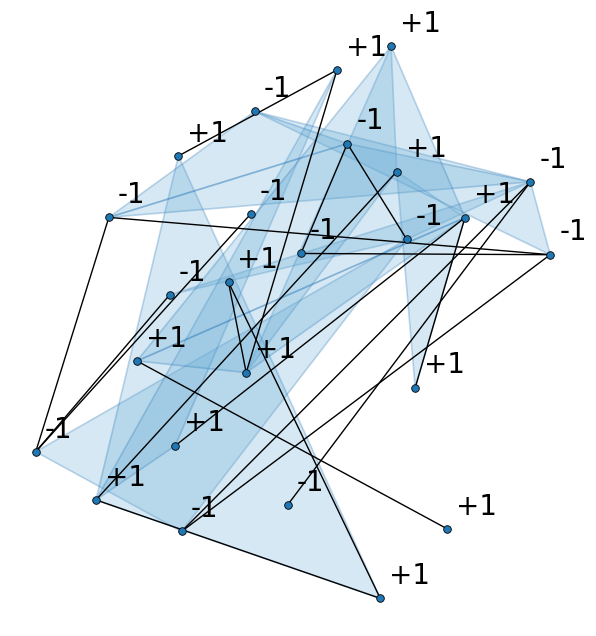

In [ ]:
import random
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Layout helper: compact "pile" positions with min distance
def generate_pile_positions(V, radius=1.0, min_dist=0.18, seed=4, max_tries=50_000):
    """
    Place nodes randomly in a disk of given radius, enforcing a minimum distance
    between any two nodes. Produces a compact 'pile' layout.
    """
    random.seed(seed)
    pos = {}
    tries = 0

    for v in V:
        placed = False
        while not placed:
            tries += 1
            if tries > max_tries:
                raise RuntimeError(
                    "Could not place all vertices. Try decreasing min_dist or increasing radius."
                )

            # Sample uniformly in a disk
            r = radius * np.sqrt(random.random())
            theta = 2 * np.pi * random.random()
            x = r * np.cos(theta)
            y = r * np.sin(theta)

            # Enforce minimum distance to existing points
            if all(np.hypot(x - px, y - py) >= min_dist for px, py in pos.values()):
                pos[v] = (x, y)
                placed = True

    return pos


# HSBM generator (generalized: r=2 and r=3 layers)
def generalized_hsbm_2_3(n, p2, q2, p3, q3, *, seed=1, balanced=True):
    """
    Generalized stochastic block hypergraph model with r=2 and r=3 layers.

    Labels sigma(i) in {-1,1}.
      - Pair {i,j} included with prob p2 if same label, else q2.
      - Triple {i,j,k} included with prob p3 if all same label, else q3.

    Returns
    -------
    V     : list of vertices
    sigma : dict {i: -1 or +1}
    E2    : list of 2-edges (tuples)
    E3    : list of 3-hyperedges (tuples)
    """
    random.seed(seed)
    V = list(range(1, n + 1))

    # labels
    if balanced:
        labels = [-1] * (n // 2) + [1] * (n - n // 2)
        random.shuffle(labels)
        sigma = {V[i]: labels[i] for i in range(n)}
    else:
        sigma = {i: random.choice([-1, 1]) for i in V}

    # r=2 layer
    E2 = []
    for (i, j) in combinations(V, 2):
        prob = p2 if sigma[i] == sigma[j] else q2
        if random.random() < prob:
            E2.append((i, j))

    # r=3 layer
    E3 = []
    for (i, j, k) in combinations(V, 3):
        all_same = (sigma[i] == sigma[j] == sigma[k])
        prob = p3 if all_same else q3
        if random.random() < prob:
            E3.append((i, j, k))

    return V, sigma, E2, E3



# New drawing function, with +-1 on the nodes
def draw_hypergraph_simplicial_with_sigma(
    n,
    edges=None,
    hyperedges=None,
    sigma=None,
    *,
    node_labels=False,
    radius=1.0,
    min_dist=0.18,
    layout_seed=4,
    node_size=30,
    node_color="#1f77b4",
    node_edgecolor="black",
    node_linewidth=0.6,
    edge_color="black",
    edge_width=1.0,
    face_color="#6baed6",
    face_alpha=0.35,
    outline_color="#2171b5", 
    outline_width=1.2,
    figsize=(6.5, 6.5),
    title=None,
    filename_base=None,
    dpi=400
):
    V = list(range(1, n + 1))
    edges = edges or []
    hyperedges = hyperedges or []
    sigma = sigma or {}

    # compact pile layout
    pos = generate_pile_positions(
        V,
        radius=radius,
        min_dist=min_dist,
        seed=layout_seed
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.axis("off")

    # Draw hyperedges (filled triangles with blue outline)
    for he in hyperedges:
        he = tuple(he)
        if len(he) < 3:
            continue

        pts = np.array([pos[v] for v in he])
        poly = Polygon(
            pts,
            closed=True,
            facecolor=face_color,
            edgecolor=outline_color,
            linewidth=outline_width,
            alpha=face_alpha,
            zorder=1
        )
        ax.add_patch(poly)

    #Draw 2-edges (black)
    for (u, v) in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        ax.plot([x1, x2], [y1, y2],
                color=edge_color,
                linewidth=edge_width,
                zorder=2)

    #Draw nodes
    xs = [pos[v][0] for v in V]
    ys = [pos[v][1] for v in V]
    ax.scatter(
        xs, ys,
        s=node_size,
        color=node_color,
        edgecolors=node_edgecolor,
        linewidths=node_linewidth,
        zorder=3
    )

    # (existing) node id labels
    if node_labels:
        for v in V:
            x, y = pos[v]
            ax.text(x, y, str(v),
                    ha="center", va="center",
                    fontsize=8, color="white",
                    zorder=4)

    # sigma labels next to nodes: "+1" or "-1"
    dx = 0.03 * radius
    dy = 0.03 * radius
    for v in V:
        if v in sigma:
            x, y = pos[v]
            ax.text(x + dx, y + dy, f"{sigma[v]:+d}",
                    ha="left", va="bottom",
                    fontsize=20, color="black",
                    zorder=5)

    if title is not None:
        ax.set_title(title, fontsize=11)

    plt.tight_layout()

    if filename_base:
        plt.savefig(f"{filename_base}.png", dpi=dpi, bbox_inches="tight")
        plt.savefig(f"{filename_base}.pdf", bbox_inches="tight")

    plt.show()



n=25 

if __name__ == "__main__":

    # probabilities for generalized HSBM (r=2 and r=3)
    p2, q2 = 0.07, 0.04
    p3, q3 = 0.006, 0.003

    V, sigma, E2, E3 = generalized_hsbm_2_3(
        n=n,
        p2=p2, q2=q2,
        p3=p3, q3=q3,
        seed=1,
        balanced=True
    )


    draw_hypergraph_simplicial_with_sigma(
        n=n,
        edges=E2,
        hyperedges=E3,
        sigma=sigma,
        node_labels=False,
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="HSBM_first"
    )

if __name__ == "__main__":

    # probabilities for generalized HSBM (r=2 and r=3)
    p2, q2 = 0.10, 0.02
    p3, q3 = 0.015, 0.002

    V, sigma, E2, E3 = generalized_hsbm_2_3(
        n=n,
        p2=p2, q2=q2,
        p3=p3, q3=q3,
        seed=1,
        balanced=True
    )

    draw_hypergraph_simplicial_with_sigma(
        n=n,
        edges=E2,
        hyperedges=E3,
        sigma=sigma,
        node_labels=False,
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="HSBM_second"
    )

if __name__ == "__main__":

    # probabilities for generalized HSBM (r=2 and r=3)
    p2, q2 = 0.14, 0.008
    p3, q3 = 0.030, 0.0008

    V, sigma, E2, E3 = generalized_hsbm_2_3(
        n=n,
        p2=p2, q2=q2,
        p3=p3, q3=q3,
        seed=1,
        balanced=True
    )


    draw_hypergraph_simplicial_with_sigma(
        n=n,
        edges=E2,
        hyperedges=E3,
        sigma=sigma,
        node_labels=False, 
        radius=1.0,
        min_dist=0.18,
        layout_seed=4,
        node_size=30,
        face_alpha=0.28,
        filename_base="HSBM_third"
    )